STEP 0: Install Required Libraries and Download Dataset

In [8]:
!apt-get update && apt-get install -y wget unzip
!pip install open3d imageio matplotlib opencv-python --quiet
!pip install open3d[visualization] plotly --quiet

# Download TUM Freiburg1/xyz dataset (RGB-D)
!wget -q https://vision.in.tum.de/rgbd/dataset/freiburg1/rgbd_dataset_freiburg1_xyz.tgz
!tar -xzf rgbd_dataset_freiburg1_xyz.tgz

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

Definitions and Importance


    Depth estimation aims to determine the distance from the camera to every point in the scene.
    RGB-D = RGB (color image) + Depth (each pixel's distance)

    Uses: 3D mapping, navigation, robotics, AR/VR, medical imaging.

    We use RGB-D pairs from the TUM dataset

STEP 1: Load One RGB-D Pair from Dataset

In [9]:
import os
import imageio
import numpy as np
import matplotlib.pyplot as plt

# Check available filenames
rgb_dir = "rgbd_dataset_freiburg1_xyz/rgb"
depth_dir = "rgbd_dataset_freiburg1_xyz/depth"

# Print first few filenames
rgb_files = sorted(os.listdir(rgb_dir))
depth_files = sorted(os.listdir(depth_dir))

print("Sample RGB Image:", rgb_files[10])
print("Sample Depth Image:", depth_files[10])

# Load matching RGB and Depth frame
rgb_path = os.path.join(rgb_dir, rgb_files[10])
depth_path = os.path.join(depth_dir, depth_files[10])

rgb = imageio.v2.imread(rgb_path)
depth = imageio.v2.imread(depth_path).astype(np.float32) / 5000.0  # mm → meters

Sample RGB Image: 1305031102.511219.png
Sample Depth Image: 1305031102.494271.png


STEP 2: Display RGB and Depth Images

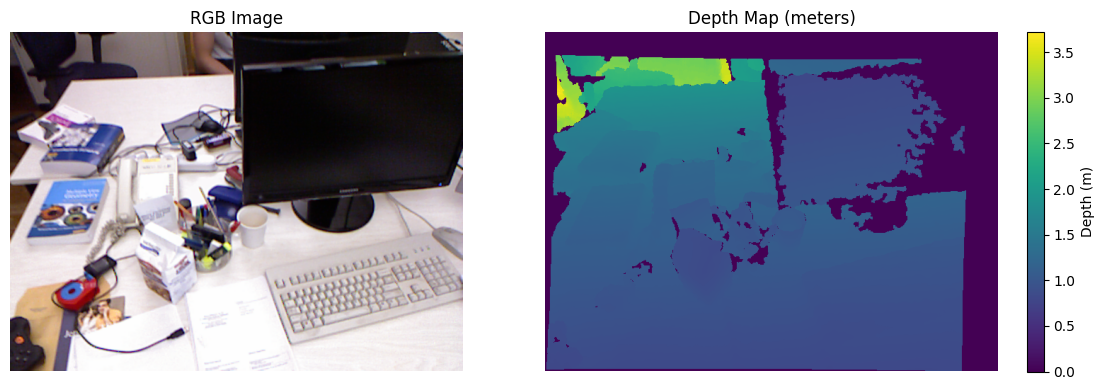

In [10]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.imshow(rgb); plt.title("RGB Image"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(depth, cmap='viridis'); plt.title("Depth Map (meters)")
plt.colorbar(label='Depth (m)'); plt.axis("off")
plt.tight_layout()
plt.show()

STEP 3: 3D Point Cloud Generation Using Open3D

In [11]:
import open3d as o3d

# Convert images to Open3D format
rgb_o3d = o3d.geometry.Image(rgb)
depth_o3d = o3d.geometry.Image((depth * 1000).astype(np.uint16))  # back to mm

# Create RGBD image
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    rgb_o3d, depth_o3d,
    depth_scale=1000.0,           # because it's in mm
    convert_rgb_to_intensity=False
)

# Camera intrinsics (from TUM Freiburg1 settings)
fx, fy = 517.3, 516.5
cx, cy = 318.6, 255.3
intrinsics = o3d.camera.PinholeCameraIntrinsic(
    width=rgb.shape[1], height=rgb.shape[0],
    fx=fx, fy=fy, cx=cx, cy=cy
)

# Generate point cloud
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_image, intrinsics)

# Flip axis for correct visualization
pcd.transform([[1, 0, 0, 0],
               [0, -1, 0, 0],
               [0, 0, -1, 0],
               [0, 0, 0, 1]])

PointCloud with 227013 points.

STEP 4: Visualize the 3D Point Cloud

In [14]:
from open3d.visualization import draw_plotly
draw_plotly([pcd])

Output hidden; open in https://colab.research.google.com to view.

STEP 5: Histogram Analysis of Depth

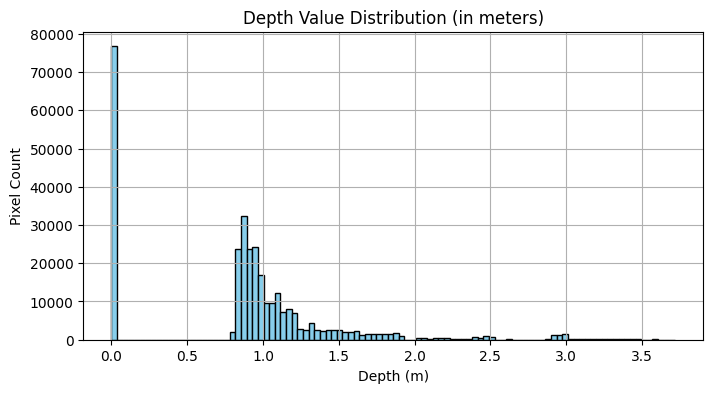

In [15]:
plt.figure(figsize=(8,4))
plt.hist(depth.flatten(), bins=100, color='skyblue', edgecolor='black')
plt.title("Depth Value Distribution (in meters)")
plt.xlabel("Depth (m)")
plt.ylabel("Pixel Count")
plt.grid(True)
plt.show()

What This Code Does:

| Step | Task      | Description                               |
| ---- | --------- | ----------------------------------------- |
| 1️⃣  | Load      | RGB and depth images from TUM dataset     |
| 2️⃣  | Visualize | Display RGB and depth                     |
| 3️⃣  | Convert   | To Open3D RGBD format                     |
| 4️⃣  | Estimate  | 3D point cloud using pinhole camera model |
| 5️⃣  | Visualize | Render the point cloud in 3D              |
| 6️⃣  | Analyze   | Histogram of depth values                 |
